<a href="https://colab.research.google.com/github/sbednarz/ModelowanieProcesowBiotechnologicznych2026/blob/main/kinetyka_bioproces%C3%B3w/04_godia_start.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

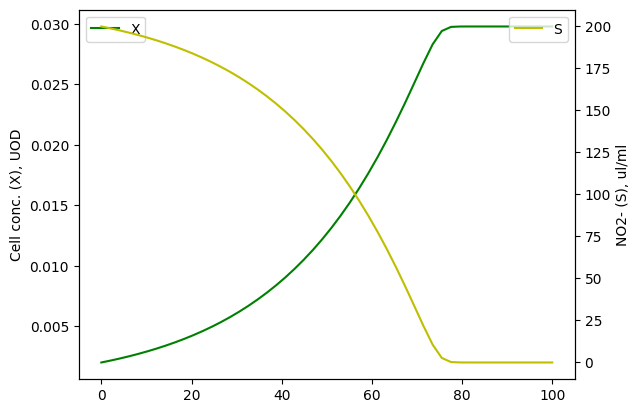

In [3]:
# Kod początkowy - do modyfikacji

import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import odeint

# Wzrost Monoda
def model(y, t):
    X = y[0]
    S = y[1]
    mi = mi_max*S/(KM+S)     # specyficzne tempo wzrostu
    dXdt = X * mi            # wzrost biomasy (np. komórek nitrobacter)
    dSdt = -1/Y * X * mi     # pobieranie substratu ograniczającego
    return [dXdt, dSdt]

mi_max = 0.0382 # maksymalne specyficzne tempo wzrostu komórek
KM = 6 # stała nasycenia
Y = 0.139e-3 # Współczynnik wydajności

# Warunki początkowe
X0 = 0.002  # O.D.
S0 = 200    # azotyny ug/ml


# Symulacja fermentacji
t = np.linspace(0, 100)
results = odeint( model, [X0, S0], t)
X = results[:,0]
S = results[:,1]
ax1 = plt.subplot(111)
ax1.plot(t,X, 'g', label='X')
ax1.set_ylabel('Stężenie komórek (X), UOD')
ax1.legend(loc='upper left')
ax2 = ax1.twinx()
ax2.plot(t,S, 'y', label='S')
ax2.set_ylabel('NO2- (S), ug/ml')
ax2.set_xlabel('Czas, h')
ax2.legend(loc='upper right')
plt.show()